# Intensity sampling

## 1. Multi-Otsu Thresholding

### *This module creates sub-partitions inside optical classes, specified by multi-Otsu thresholding.*

The main assumption here is that (an mostly at later timepoints) pixels can be classified as parts of:
- **i)** a very bright class.
- **b)** a class with nuclei of medium intensity
- **c)** a class of intensities of auto- fluorescence and dim nuclei and 
- **d)** Noise  

But Multi-Otsu for 4 classses will just output 3 intensity values. This module peaks intermediate intensity values These values will be the thresholds for the adaptive mask

In [1]:
from pathlib import Path
import napari 
import sys
import tifffile
from lineagetree import LineageTree, read_from_mastodon
import numpy as np
from skimage.measure import regionprops
import matplotlib.pyplot as plt
from ipywidgets import IntSlider, interactive
from ipywidgets import Layout
import h5py
from scipy.ndimage import gaussian_filter, median_filter, grey_erosion
from skimage.filters import threshold_otsu, threshold_multiotsu, sobel
from skimage.segmentation import watershed

# CUSTOM FUNCTIONS
from watermasks.utils import paths, import_registration_mats_multiview, registered_position_of_id_in_t, paint_annotations, view_overlays_3d_V2, block_timer

In [2]:
# --- PARAMETER SETTING ---
TP = 500
VIEW = '0'

In [3]:
# --- IMPORT DATA AND FILES ---
path_h5, path_xml, path_mast, dir_input_images, dir_output_masks = paths()

# LOAD INPUT IMAGE
with h5py.File(path_h5, "r") as f5:
    test_image = f5[f't00{TP}']['s00']['2']['cells'][:]

# LOAD REG. MATRICES AND LINEAGETREE
R_of_t = import_registration_mats_multiview(path_xml, TP-5,TP+5)
lT = read_from_mastodon(path_mast)

shape_full_h5 = np.array([300, 1888, 2100]) # as measured in T7_3 data (dir = H:)
shape_test_image = np.array(np.shape(test_image))
scaling = shape_test_image/shape_full_h5
print(f'full image shape = {shape_full_h5}\n2nd h5 layer has shape = {shape_test_image} \n-scaling ratio is [z, y, x] = {scaling}')

# GET THE REGISTERED MASTODON POSITIONS
reg_pos_at_t = []
for mastodon_id_t in lT.time_nodes[TP]:
    x, y, z = registered_position_of_id_in_t(mastodon_id_t, lT, TP, R_of_t, VIEW, scaling)
    reg_pos_at_t.append([x, y, z])
reg_pos_at_t = np.asarray(reg_pos_at_t)

# --- VISUALIZE THE ANNOTATIONS ---
an_space = an_space = paint_annotations(TP, lT, shape_test_image,R_of_t,scaling,VIEW,1)

transformations extracted for all views from xml


c:\Users\Tassos\miniconda3\envs\watersh\lib\site-packages\lineagetree\_io\_loaders.py:895: UserWarning: The provided `time` dictionary had keys that were not nodes. They have been removed
  return LineageTree(


full image shape = [ 300 1888 2100]
2nd h5 layer has shape = [300 472 525] 
-scaling ratio is [z, y, x] = [1.   0.25 0.25]
done painting


In [4]:
# # EXPORT THE USED H5 IMAGE (HERE 2ND H5 LAYER) FOR LATER USE AS THE TRAINING STARDIST DATASET
# tifffile.imwrite(dir_input_images+f"\\cells_t00{str(TP)}.tif", test_image)
# # run once

In [4]:
# --- IMAGE PRE-PROCESSING ---

# PARAMETERS
EROSION_RADIUS = 7 # after tweaking 

im = test_image
pos_array = np.array([p[::-1] for p in reg_pos_at_t]).round().astype(np.uint16)
im_gauss = gaussian_filter(im, sigma=1)
im_gauss_median = median_filter(im_gauss, size=1) # this seems that is not doing much! (inspection by eye)

erosion = grey_erosion(im_gauss_median, size=EROSION_RADIUS)
im_for_ws = im_gauss_median - erosion
im_ws_gauss = gaussian_filter(im_for_ws, sigma = 0.75)

In [5]:
# --- EDITING THE ADAPTIVE MASK LOOP ---

# PARAMETERS
INTENSITY_FLOOR = 10

# CREATE THE FIRST IGNORE MASK
ignore_mask = []
ignore_mask = im_gauss_median < INTENSITY_FLOOR

In [7]:
# OTSU FOR DIFFERENT NUMBER OF  OPTICAL CLASSES
with block_timer():
    th_otsu = threshold_otsu(im_for_ws)
    print('for single Otsu :')

with block_timer():
    print('for n= 3 optical classes :')
    th_multi_otsu = threshold_multiotsu(im_for_ws, 3)

with block_timer():
    print('for n= 4 optical classes :')
    th_multi_otsu_4class = threshold_multiotsu(im_for_ws, 4)

print(f"Simple Otsu threshold = {th_otsu}"+"\n"+f"Multi Otsu tresholds, 3 classes = {th_multi_otsu}"+"\n"+f"Multi Otsu tresholds, 4 classes = {th_multi_otsu_4class}")

for single Otsu :
-(Time elapsed: 0.448822 s)

for n= 3 optical classes :
-(Time elapsed: 0.495316 s)

for n= 4 optical classes :
-(Time elapsed: 18.595729 s)

Simple Otsu threshold = 37
Multi Otsu tresholds, 3 classes = [ 26 113]
Multi Otsu tresholds, 4 classes = [ 18  60 189]


In [ ]:
# # --- VISUALIZE THINGS THUS FAR ---
# %matplotlib widget
# view_overlays_3d_V2([test_image, im_gauss_median, erosion, im_for_ws, im_ws_gauss, ~ignore_mask],\
#                     ['Original', 'Median(Gauss)', 'Erosion', 'Median - Erosion', 'Gauss(M - E)', 'Keep mask'],\
#                         ['gray', 'gray', 'viridis', 'gray', 'gray', 'binmap'],\
#                             [1,1,1,1,1,0.5], same_contrast=False)

In [9]:
# FIRST IMPLEMENTATION OF INTNESITY SLICING
# def intensity_slicing(thresholds_list, steps = 5, intensity_max=500, intensity_min=10, linear_slicing=True):
    
#     if linear_slicing == True:
    
#         if len(thresholds_list) == 1: #if single otsu is applied
#             intensity_list = [intensity_max, *range(thresholds_list[0], intensity_min, -int((thresholds_list[0]-intensity_min)/(steps*2))), intensity_min]

#         if len(thresholds_list) == 2:
#             # intensity_list = ([intensity_max, (intensity_max + thresholds_list[1])/2, *range(int(thresholds_list[1]), int(thresholds_list[0]), -int((thresholds_list[1]-thresholds_list[0])/(steps))), intensity_min])
#             intensity_list = ([ *range(intensity_max, int(thresholds_list[1]),-int((intensity_max-thresholds_list[1])/(steps))), # start with the max intensity value and interate to the 1st sobel threshhold
#                                             *range(int(thresholds_list[1]), int(thresholds_list[0]), -int((thresholds_list[1]-thresholds_list[0])/(steps))), # interate between thresholds
#                                                 intensity_min]) # also sample a small intensity for good mesure

#         intensity_list = np.asarray(intensity_list)
#         intensity_list.flatten
#     return intensity_list

In [10]:
import numbers

# NEW IMPLEMENTATION OF INTNESITY SLICING
def intensity_slicing(thresholds_list, steps=[3,4,3], intensity_max=500, intensity_min=10, pct_difference:float=0.1, linear_slicing=True) -> list: 

    """A function that outputs a list of multiple intensity values, given a list of thresholds or a single threshhold. Applicable to e.g. Otsu and multi-Otsu thresholds.

    Args:
        thresholds_list (_type_): input the number of thresholds
        steps (int, optional): how many intensity samples will be included from each threshold limit. Defaults to 5.
        pct_difference (float, optional): If two values are closser apart than this percentage, the largest is skipped  
        intensity_max (int, optional): The starting minnimumintensity. Defaults to 500.
        intensity_min (int, optional): The minimum allowable intensity in your dataset. Defaults to 10.
        linear_slicing (bool, optional): Opening up the posibility of choosing a nonlinear sequence. Defaults to True.

    Raises:
        ValueError: If the set of values of interations in each class is more than the optical classes
        ValueError: If the the starting intensity is smaller than expected (smaller that the largest Otsu threshold)
    
    Returns:
        list: a list intensity values for the adaptive ws mask.  
    """
    # CHECK INPUTS
    if intensity_max <= thresholds_list[-1]:
        raise ValueError("Starting intensity is bellow largest Otsu threshold")

    if len(steps) < (len(thresholds_list)+1):
        raise ValueError("Not enough boundary partitions given")
    
    elif len(steps) < len(thresholds_list)+1:
        raise ValueError("Too many partitions given")
    
    # MAKE THE LIST
    intensity_list = []
    if linear_slicing == True: # Maybe non linear functionality will be added later.

        if isinstance(thresholds_list, np.ndarray) or isinstance(thresholds_list, list) :
            intensity_list.append([*range(intensity_max, int(thresholds_list[-1]), -int((intensity_max-thresholds_list[-1])/(steps[0])))])
            # the first sampling is between (maximum intensity value, higher otsu value)
            for i in range(len(thresholds_list)-1):
                intensity_list.append([*range(int(thresholds_list[-(i+1)]), int(thresholds_list[-(i+2)]), -int((thresholds_list[-(i+1)]-(thresholds_list[-(i+2)]))/(steps[i+1])))])
                # next sampling is done between intermetiate otsu values
            intensity_list.append([*range(thresholds_list[0], intensity_min, -int((thresholds_list[0]-intensity_min)/(steps[-1])))])
            # the last sampling is between (min_int, lower Otsu valule)

        elif isinstance(thresholds_list, numbers.Integral): # for single Otsu
                intensity_list = [intensity_max, *range(thresholds_list, intensity_min, -int((thresholds_list-intensity_min)/(steps*2))), intensity_min]
        
        else:
            print('Error: Invalid threshold object type, only accepts: int, list, np.ndarray')

        # "BOTOX" YOUR LIST AND MAKE IT USABLE
        intensity_list = [j for i in intensity_list for j in i]
        # denest

        i=0
        while i < len(intensity_list) - 1:
            if abs(intensity_list[i] - intensity_list[i + 1])/intensity_list[i] <= pct_difference:
                del intensity_list[i + 1]   # remove one of the pair, if consecutive values are too close together
            else:
                i += 1
        
        # intensity_list.append(intensity_min)
        intensity_list = np.asarray(intensity_list)
        # make it an np.array

    return intensity_list[::-1]

In [11]:
lst = intensity_slicing(th_multi_otsu,[5,5,5])
print(lst)

[ 11  14  17  20  23  28  45  62  79  96 115 192 269 346 423 500]


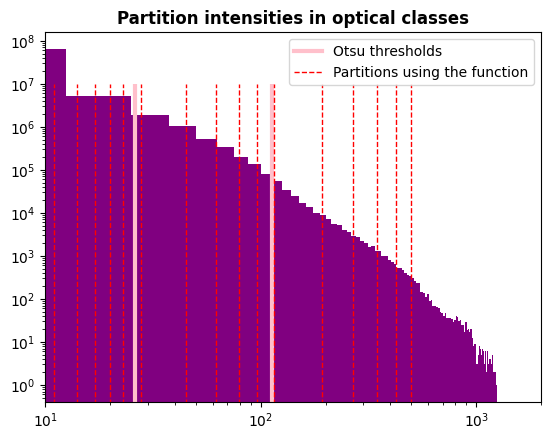

In [12]:
from matplotlib.lines import Line2D
# VISUALIZE THE PARTITIONS OF CLASESS
flat_im = im_ws_gauss.ravel()

for i in th_multi_otsu:
    plt.vlines(x=i, ymin=0, ymax=10**7, linewidth=3, color='pink')
for i in lst:
    plt.vlines(x=i, ymin=0, ymax=10**7, linewidth=1, color='red', linestyles='--')

legend_elements = [
    Line2D([0], [0], color='pink', linestyle='-', linewidth=3, label='Otsu thresholds'),
    Line2D([0], [0], linewidth=1, color='red', linestyle='--', label='Partitions using the function')
]
    
plt.hist(flat_im, color='purple', bins=100)
plt.yscale('log')
plt.xscale('log')
plt.xlim(10, 2000)
# plt.ylim(1,5*10**6)
plt.title('Partition intensities in optical classes', weight='bold')
plt.legend(handles=legend_elements)
plt.show() 

In [13]:
starting_min_intensity=500 # min intensity value a the beggining of the loop
min_mask_floor_limit=10 # intensity is never accepted bellow this value
percent_of_th=100
min_th_vol=100
max_th_vol=3000
total_steps=10

pos_array = np.array([p[::-1] for p in reg_pos_at_t]).round().astype(np.uint16)
seeds = np.zeros_like(im)
seeds[tuple(pos_array.T)] = np.arange(1, len(reg_pos_at_t) + 1)
all_seeds = set(np.unique(seeds)) - {0}

vols = {}
# Remove bad initialization

def get_mask(current_min_intensity, global_min_intensity_):
    thresh_val = max(current_min_intensity, global_min_intensity_)
    return thresh_val, (im_for_ws > thresh_val) & (~ignore_mask) # returns True at positions where intensity is greater than the threshhold, if pixel should not be ignored according to original ignore_mask.

# FIRST WATERSHED, STARTING WITH 
ws = watershed(np.max(im_ws_gauss) - im_ws_gauss, seeds, mask=get_mask(starting_min_intensity, starting_min_intensity)[1])
print(f"First applied thershold = {starting_min_intensity}")

# FIRST FILTERING
# Yes, it could be part of the main while loop.
unique, counts = np.unique_counts(ws)
vols = dict(zip(unique, counts))
for s, v in vols.items():
    if s != 0 and (v < min_th_vol or v > max_th_vol): # don't check the background
        ws[ws == s] = 0
ws0 = ws.copy()
# Visualize the initial, segmentation, OLNLY FOR TESTING

missed_seeds = all_seeds - set(np.unique(ws))
print("- starting missing:", len(missed_seeds))

inc = 1 # for visualization reasons
for inte in intensity_slicing(th_multi_otsu,[3,4,7], 800)[::-1]: #<-------- change he list to change the method for intensity selection
    with block_timer(): # Toggle it if you want to time each interation
        if not missed_seeds:
            break
        
        current_thresh, mask = get_mask(inte, min_mask_floor_limit) #  Lowest intensity is dectated by the intensities partitions
        print(f"*Applied thershold = {current_thresh}")
        new_ws = watershed(np.max(im_for_ws) - im_for_ws, seeds, mask=mask)

        unique, counts = np.unique_counts(new_ws)
        vols = dict(zip(unique, counts))

        for s in missed_seeds.intersection(vols.keys()):
            if s != 0 and min_th_vol < vols[s] < max_th_vol:
                ws[new_ws == s] = s

        if inc == 1:
            ws1 = ws.copy()
            # Visualize the first interation of th segmentation image, OLNY FOR TESTING

        missed_seeds = all_seeds - set(np.unique(ws))
        inc+=1
        print("-- missing:", len(missed_seeds))

First applied thershold = 500
- starting missing: 797
*Applied thershold = 800
-- missing: 797
-(Time elapsed: 4.241295 s)

*Applied thershold = 571
-- missing: 797
-(Time elapsed: 3.993617 s)

*Applied thershold = 342
-- missing: 784
-(Time elapsed: 4.721723 s)

*Applied thershold = 113
-- missing: 550
-(Time elapsed: 16.535736 s)

*Applied thershold = 92
-- missing: 435
-(Time elapsed: 10.442906 s)

*Applied thershold = 71
-- missing: 306
-(Time elapsed: 10.923121 s)

*Applied thershold = 50
-- missing: 172
-(Time elapsed: 12.015157 s)

*Applied thershold = 29
-- missing: 152
-(Time elapsed: 7.556065 s)

*Applied thershold = 26
-- missing: 151
-(Time elapsed: 6.907911 s)

*Applied thershold = 22
-- missing: 148
-(Time elapsed: 8.227976 s)

*Applied thershold = 18
-- missing: 147
-(Time elapsed: 8.985920 s)

*Applied thershold = 16
-- missing: 147
-(Time elapsed: 9.779701 s)

*Applied thershold = 14
-- missing: 145
-(Time elapsed: 10.820528 s)

*Applied thershold = 12
-- missing: 143


In [14]:
l_tot=len(lT.time_nodes[TP])
l_missed = len(missed_seeds)
sig=3
print(f'out of {l_tot} annotations, missed {l_missed}({l_missed/l_tot*100:.3g}%)')

out of 802 annotations, missed 143(17.8%)


In [15]:
viewer = napari.Viewer()
viewer.add_image(im_ws_gauss) # the one used for watershed
viewer.add_image(an_space, colormap='green') # my annotations
viewer.add_image(ws0) # the segmentation mask at the first interation
viewer.add_labels(ws, opacity=0.7) # the segmentation at the end
napari.run()

In [16]:
# # CHECK A SUSPICIOUS VOLUME
# unique, counts = np.unique_counts(ws)
# vols = dict(zip(unique, counts))
# vols[112] 

The results are not jaw-drop inducers, but to be fair, at timepoint=500 the combination of images and annotations doesn't make it particulary easy for the segmentation algorithm.

timepoint = 500:

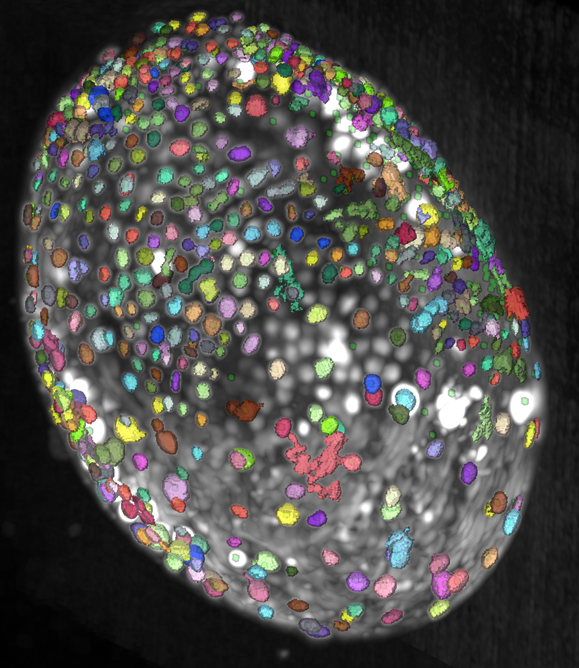

## Make the intensity filter work with percentages of pixel intensities

In [6]:
thresholds = {}
flat_im = im_for_ws[im_for_ws > 10]
flat_im = flat_im[flat_im < 500]
flat_im.ravel()
# exp_flat = np.exp(flat_im)

percentages = [
    99.99,
    99.9,
    99,
    97,
    95,
    92,
    90,
    85, 70, 60, 50, 40, 30, 20, 10]
    # '''80,
    # 75, 70, 60, 50, 30, 10'''
thresholds = {pct : np.percentile(flat_im, pct) for pct in percentages}

for first, second in thresholds.items():
    print(f'{first}%      ---->      {second}')  

99.99%      ---->      456.0
99.9%      ---->      305.1730000022799
99%      ---->      132.0
97%      ---->      89.0
95%      ---->      72.0
92%      ---->      58.0
90%      ---->      51.0
85%      ---->      41.0
70%      ---->      26.0
60%      ---->      20.0
50%      ---->      17.0
40%      ---->      15.0
30%      ---->      13.0
20%      ---->      12.0
10%      ---->      11.0


In [ ]:
starting_min_intensity=500 # min intensity value a the beggining of the loop
min_mask_floor_limit=10 # intensity is never accepted bellow this value
percent_of_th=100
min_th_vol=300
max_th_vol=1500
total_steps=10

pos_array = np.array([p[::-1] for p in reg_pos_at_t]).round().astype(np.uint16)
seeds = np.zeros_like(im)
seeds[tuple(pos_array.T)] = np.arange(1, len(reg_pos_at_t) + 1)
all_seeds = set(np.unique(seeds)) - {0}

vols = {}
# Remove bad initialization

def get_mask(current_min_intensity, global_min_intensity_):
    thresh_val = max(current_min_intensity, global_min_intensity_)
    return thresh_val, (im_for_ws > thresh_val) & (~ignore_mask) # returns True at positions where intensity is greater than the threshhold, if pixel should not be ignored according to original ignore_mask.

# FIRST WATERSHED, STARTING WITH 
ws = watershed(np.max(im_ws_gauss) - im_ws_gauss, seeds, mask=get_mask(starting_min_intensity, starting_min_intensity)[1])
print(f"First applied thershold = {starting_min_intensity}")

# FIRST FILTERING
# Yes, it could be part of the main while loop.
unique, counts = np.unique_counts(ws)
vols = dict(zip(unique, counts))
for s, v in vols.items():
    if s != 0 and (v < min_th_vol or v > max_th_vol): # don't check the background
        ws[ws == s] = 0
ws0 = ws.copy()
# Visualize the initial, segmentation, OLNLY FOR TESTING

missed_seeds = all_seeds - set(np.unique(ws))

found_seeds = {}
pct1 = 100
found_seeds[pct1] = len(all_seeds - missed_seeds)
print("- starting missing:", len(missed_seeds))

inc = 1 # for visualization reasons
for pct, current_threshold in thresholds.items(): #<-------- change he list to change the method for intensity selection
    with block_timer(): # Toggle it if you want to time each interation
        if not missed_seeds:
            break
        
        current_thresh, mask = get_mask(current_threshold, min_mask_floor_limit) #  Lowest intensity is dectated by the intensities partitions
        new_ws = watershed(np.max(im_for_ws) - im_for_ws, seeds, mask=mask)
        print(f"*Applied thershold = {current_threshold} @ {pct}%")

        unique, counts = np.unique_counts(new_ws)
        vols = dict(zip(unique, counts))

        for s in missed_seeds.intersection(vols.keys()):
            if s != 0 and min_th_vol < vols[s] < max_th_vol:
                # if s == 362:
                #     print(f"!!!! vol[s=362] = {vols[s]}")
                ws[new_ws == s] = s

        if inc == 3:
            ws1 = ws.copy()
            # Visualize the first interation of th segmentation image, OLNY FOR TESTING

        missed1 = len(missed_seeds)
        missed_seeds = all_seeds - set(np.unique(ws))
        missed2 = len(missed_seeds)
        found_seeds[pct] = missed1 - missed2
        print("-- missing:", len(missed_seeds))
        inc+=1

First applied thershold = 500
- starting missing: 800
*Applied thershold = 456.0 @ 99.99%
-- missing: 798
-(Time elapsed: 5.231722 s)

*Applied thershold = 305.1730000022799 @ 99.9%
-- missing: 786
-(Time elapsed: 5.052785 s)

*Applied thershold = 132.0 @ 99%
-- missing: 698
-(Time elapsed: 9.432588 s)

*Applied thershold = 89.0 @ 97%
-- missing: 563
-(Time elapsed: 11.796254 s)

*Applied thershold = 72.0 @ 95%
-- missing: 450
-(Time elapsed: 10.330195 s)

*Applied thershold = 58.0 @ 92%
-- missing: 329
-(Time elapsed: 11.096306 s)

*Applied thershold = 51.0 @ 90%
-- missing: 267
-(Time elapsed: 8.157242 s)

*Applied thershold = 41.0 @ 85%
-- missing: 182
-(Time elapsed: 9.779594 s)

*Applied thershold = 26.0 @ 70%
-- missing: 156
-(Time elapsed: 8.769260 s)

*Applied thershold = 20.0 @ 60%
-- missing: 154
-(Time elapsed: 8.727492 s)

*Applied thershold = 17.0 @ 50%
-- missing: 151
-(Time elapsed: 9.877860 s)

*Applied thershold = 15.0 @ 40%
-- missing: 151
-(Time elapsed: 10.040978 s)

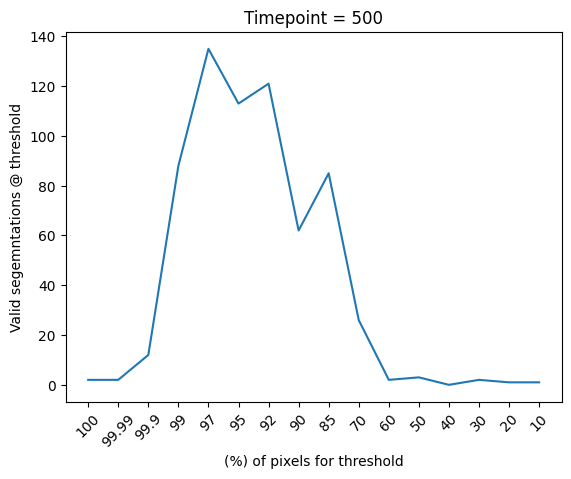

In [8]:
# WHERE DO WE FIND MOST OF THE NUCLEI? AT WHAT INTENSITY THRESHOLDS?
numbers = range(len(found_seeds.values()))
labels = [str(f'{i}') for i in found_seeds.keys()] # for the x axes

plt.plot(list(found_seeds.values()))
plt.xticks(numbers, labels, rotation=45)
plt.xlabel('(%) of pixels for threshold')
plt.ylabel('Valid segemntations @ threshold')
plt.title(f'Timepoint = {TP}')
plt.show()

In [9]:
l_tot=len(lT.time_nodes[TP])
l_missed = len(missed_seeds)
sig=3
print(f'out of {l_tot} annotations, missed {l_missed}({l_missed/l_tot*100:.3g}%)')

out of 802 annotations, missed 147(18.3%)


In [10]:
viewer = napari.Viewer()
viewer.add_image(im_ws_gauss) # the one used for watershed
viewer.add_image(an_space, colormap='green') # my annotations
viewer.add_image(ws0) # the segmentation mask at the first interation
viewer.add_labels(ws, opacity=0.7) # the segmentation at the end
napari.run()

In [ ]:
# # CHECK SUSPICIOUS VOLUME
# unique, counts = np.unique_counts(ws)
# vols = dict(zip(unique, counts))

Text(0.5, 1.0, 'Volume(Intensity)')

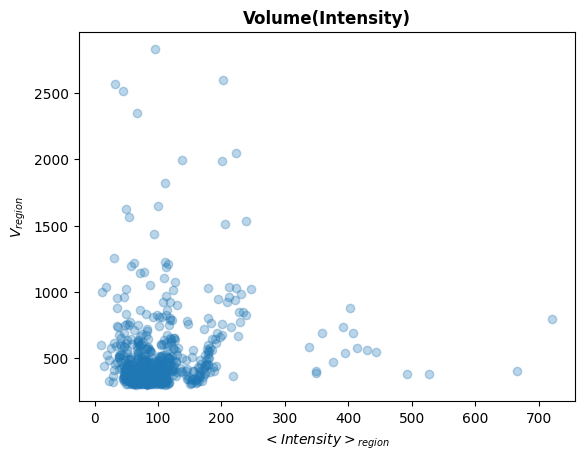

In [24]:
intemean=[]
volumakia=[]
stdevs=[]

for reg in regionprops(ws, im_ws_gauss):
    intemean.append(reg.intensity_mean)
    volumakia.append(reg.area)
    stdevs.append(reg.intensity_std)

plt.scatter(intemean, volumakia, alpha=0.3)
plt.xlabel(r'$<Intensity>_{region}$')
plt.ylabel(r'$V_{region}$')
plt.title('Volume(Intensity)', weight='bold')

Text(0.5, 1.0, 'Volume(Intensity)')

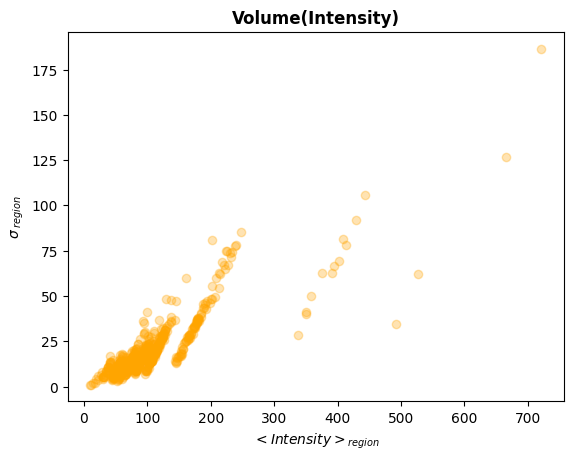

In [25]:
plt.scatter(intemean, stdevs, alpha=0.3, color='orange')
plt.xlabel(r'$<Intensity>_{region}$')
plt.ylabel(r'$\sigma_{\;region}$')
plt.title('Volume(Intensity)', weight='bold')

Text(0.5, 1.0, 'Volume(Intensity)')

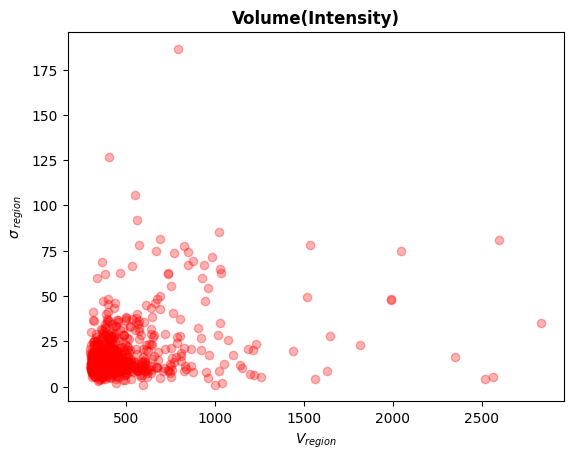

In [28]:
plt.scatter(volumakia, stdevs, alpha=0.3, color='red')
plt.xlabel(r'$V_{region}$')
plt.ylabel(r'$\sigma_{\;region}$')
plt.title('Volume(Intensity)', weight='bold')

## Make the allowed max volume a function of current intensity threshold

Could this create better quality masks? or will it be worse for training, as we have coupled intensity with region volume more than just with the mask

## Discussion

The for this notebook is in essence an atempt to find an automated function for choosing the intensities that the adaptive mask will be using as filters